True
Img shape: (155, 240, 240)
Mask shape:(155, 240, 240) max: 4.0


TypeError: Image data of dtype object cannot be converted to float

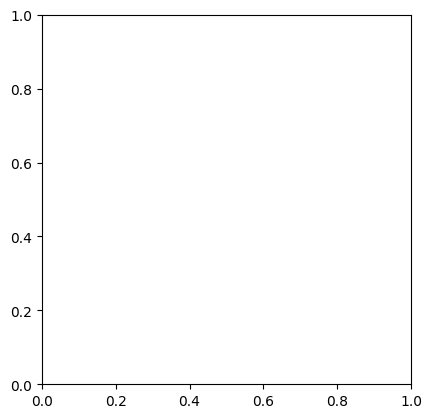

In [15]:
import sys

import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms

name = "BraTS2021_00000"
t2_path = f"C:\\bratsdata\\{name}\\{name}_t2.nii.gz"
t1_path = f"C:\\bratsdata\\{name}\\{name}_t1.nii.gz"
t1ce_path = f"C:\\bratsdata\\{name}\\{name}_t1ce.nii.gz"
t1ce_path = f"C:\\bratsdata\\{name}\\{name}_t1ce.nii.gz"
mask_path = f"C:\\bratsdata\\{name}\\{name}_seg.nii.gz"
pickle_path = f"C:\\bratsdata\\{name}\\{name}.pt"


def get_numpy_array(path):
    return sitk.GetArrayFromImage(sitk.ReadImage(path))


raw_image = sitk.ReadImage(t2_path)
raw_mask = sitk.ReadImage(mask_path)

image = sitk.GetArrayFromImage(raw_image)
mask = sitk.GetArrayFromImage(raw_mask).astype(dtype=float)

show_mask = np.copy(mask)
show_mask[show_mask == 0] = np.nan

# with open(pickle_path, "wb") as f:
np.savez_compressed(
    pickle_path,
    t1=get_numpy_array(t1_path),
    t2=get_numpy_array(t2_path),
    t1ce=get_numpy_array(t1ce_path),
    seg=get_numpy_array(mask_path),
)
loaded = np.load(pickle_path + ".npz")
print(np.array_equal(image, loaded["t2"]))
# np.save(f, image)

image_slice = [59, ...]
mask_slice = show_mask[59, ...]
print(f"Img shape: {image.shape}")
print(f"Mask shape:{mask.shape}", "max:", np.max(mask))
plt.imshow(image_slice, cmap="gray")
plt.imshow(mask_slice, alpha=0.3, cmap="viridis")


# Image normalization


Max image normal: 2421
Max image normalized: 1.0


TypeError: Image data of dtype object cannot be converted to float

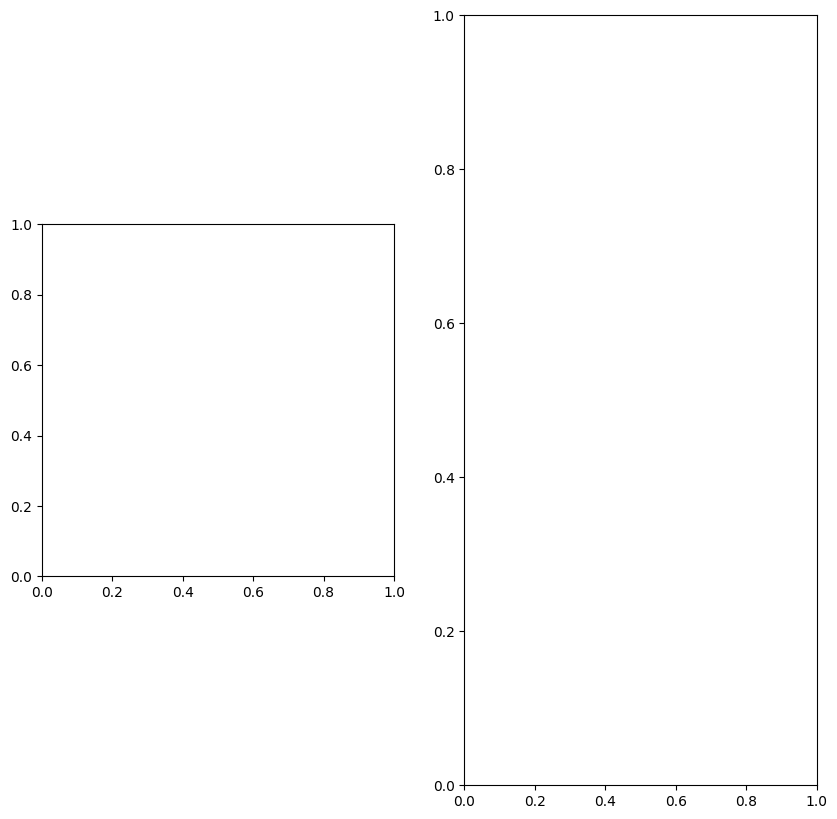

In [ ]:
normalized_image = (image - np.min(image)) / (np.max(image) - np.min(image))
normalized_image_slice = normalized_image[59, ...]

t_image = torch.as_tensor(image, dtype=torch.float)
t_image = torch.nn.functional.normalize(t_image)

print(f"Max image normal: {np.max(image)}")
print(f"Max image normalized: {torch.max(t_image)}")
fig, ax = plt.subplots(ncols=2, figsize=(10, 10))

ax[0].imshow(image_slice, cmap="gray")
ax[1].imshow(normalized_image_slice, cmap="gray")


# Normalize STD and MEAN


Max image original: 2421
Max image normalized: 4387.0


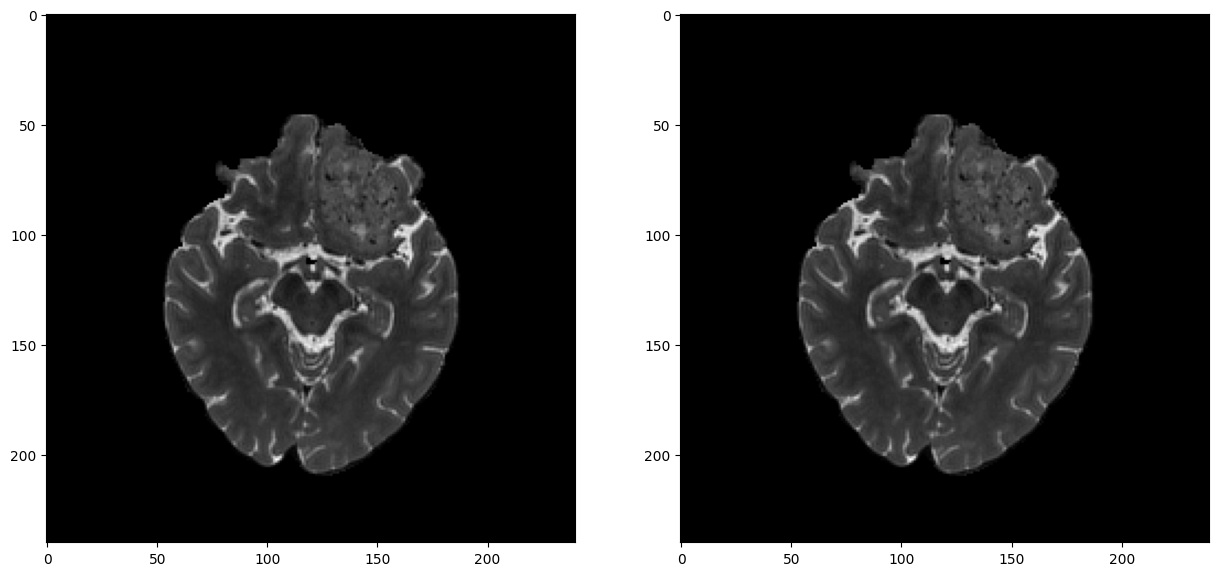

In [ ]:
t_image = torch.as_tensor(image, dtype=torch.float)
t_image = torchvision.transforms.Normalize(std=[0.5] * 155, mean=[0.5] * 155)(t_image)
t_image = t_image[59, ...]

print(f"Max image original: {np.max(image)}")
print(f"Max image normalized: {torch.max(t_image)}")
fig, ax = plt.subplots(ncols=2, figsize=(15, 15))
ax[0].imshow(image_slice, cmap="gray")
ax[1].imshow(t_image, cmap="gray")


# Prepare Mask

Outputs a tensor with a new dimension containing 4 channels.
Each channel provides a label
0: Background
1: Tumor..
....


In [ ]:
mask[
    mask == 4
] = 3  # Recode 4 to 3 so there is no gap between two and the following value
print(f"Mask shape: {mask.shape}")
t_mask = torch.as_tensor(mask, dtype=torch.float)
print(f"Shape: {mask.shape} |  Unique:{torch.unique(t_mask)}")
one_hot_encoded = torch.nn.functional.one_hot(t_mask.long(), num_classes=4)
print(f"Shape: {one_hot_encoded.shape} |  Unique:{torch.unique(one_hot_encoded)}")
one_hot_decoded = torch.argmax(one_hot_encoded, dim=-1)
print(f"Shape: {one_hot_decoded.shape} |  Unique:{torch.unique(one_hot_decoded)}")


Mask shape: (155, 240, 240)
Shape: (155, 240, 240) |  Unique:tensor([0., 1., 2., 3.])
Shape: torch.Size([155, 240, 240, 4]) |  Unique:tensor([0, 1])
Shape: torch.Size([155, 240, 240]) |  Unique:tensor([0, 1, 2, 3])


# Resize images for fitting in memory


In [ ]:
import torchio as tio
from matplotlib.animation import FuncAnimation


timg = tio.ScalarImage(t2_path)
print("org img:", timg.data.shape, "memory:", timg.memory // 1000000, "MB")
trans = tio.CropOrPad((128, 128, 128))
trans = tio.Resample((1.875, 1.875, 1.22))
out = trans(timg)
print("resample img:", out.data.shape, "memory:", out.memory // 1000000, "MB")
out.save("test.nii.gz")

fig, ax = plt.subplots(ncols=2, figsize=(15, 15))
ax[0].imshow(timg.numpy()[0, :, :, 59], cmap="gray")
ax[1].imshow(out.numpy()[0, :, :, 59], cmap="gray")


ModuleNotFoundError: No module named 'torchio'

# Dataloader


img shape: torch.Size([1, 1, 128, 64, 64])
mask shape: torch.Size([1, 4, 128, 64, 64])


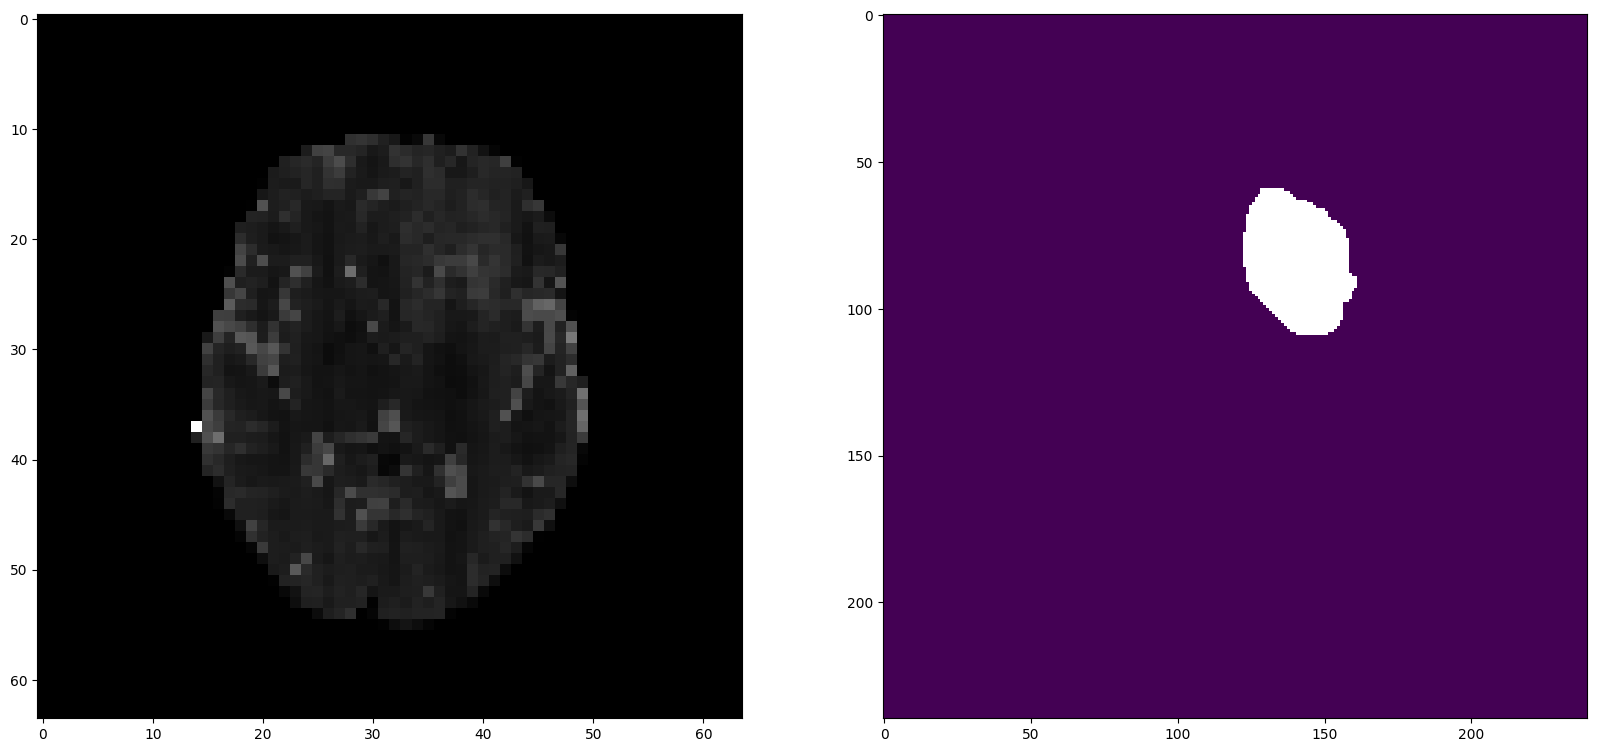

In [37]:
import dataset
from torch.utils.data import DataLoader

dataset = dataset.BratsDataset(
    image_paths=np.array([t2_path]), mask_paths=np.array([mask_path])
)
data_loader = DataLoader(dataset, batch_size=1)
image, mask = next(iter(data_loader))
label = sitk.GetArrayFromImage(sitk.ReadImage(mask_path))
label = label.astype(float)
print(f"img shape: {image.shape}")
print(f"mask shape: {mask.shape}")


fig, ax = plt.subplots(ncols=2, figsize=(20,20))
mask[mask == 0] = np.nan
#label[label== 0] = np.nan
label[label== 4] = np.nan
label[label== 2] = np.nan
label[label== 1] = np.nan
ax[0].imshow(image[0, 0, 59, :, :], cmap="gray")
#ax[1].imshow(mask[0, 0, 59, :, :], cmap="gray")
#ax[2].imshow(mask[0, 1, 59, :, :], cmap="gray")
#ax[3].imshow(mask[0, 2, 59, :, :], cmap="gray")
#ax[4].imshow(mask[0, 3, 59, :, :], cmap="gray")
ax[1].imshow(label[ 59, :, :], cmap="viridis")
